In [1]:
import numpy as np
import matplotlib.pyplot as plt
import KMC_TPD as TPD
import KMC_PtCu as PtCu
import SimParams as setup

#### Setup the simulation

In [2]:
# Setup the simulation
init = setup.sim_setup(400,1e5,100,(25,25))

def TEMP(t): return 300 + 1*t

init.build_lat('SAA','triangular',density=0.1)

Built triangular lattice for SAA system


#### Setup the TPD system from some saved kinetic parameters

In [3]:
cov_key_TPD = {0:0.2,1:0.8}
init.set_lat_occ('thetas',theta_key=cov_key_TPD)
sim_TPD = TPD.KMC(
    init.to_KMC(),
    np.load('ref_sim_params/E_a_TPD.npy'),
    np.load('ref_sim_params/A_TPD.npy'),
    TEMP,
    np.load('ref_sim_params/J_TPD.npy'),
    np.load('ref_sim_params/w_TPD.npy')
)

Lattice populated according to thetas occupancy

______________ ___________ ___________
\              \    ___   \     __    \
 \____     _____\   \__\   \    \ \    \
      \    \     \     _____\    \ \    \
       \    \     \    \     \    \_\    |
        \    \     \    \     \         /
         \____\     \  __\     \_______/ 
----------------------------------------------------------------------
|      Time-dependent Kinetic Monte Carlo for surface catalysis      |
|       Script written by Sam Oades for MChem part II project        |
----------------------------------------------------------------------
|     Intialising triangular lattice system on a 25x25 supercell     |
|              Kinetic parameters saved in 625x8 array               |
----------------------------------------------------------------------


#### Setup the PtCu system from some saved kinetic parameters

In [4]:
cov_key_PtCu = {0:0.2,1:0.65,5:0.15}
init.set_lat_occ('thetas',theta_key=cov_key_PtCu)
sim_PtCu = PtCu.KMC(
    init.to_KMC(),
    np.load('ref_sim_params/E_a_PtCu.npy'),
    np.load('ref_sim_params/A_PtCu.npy'),
    TEMP,
    np.load('ref_sim_params/J_PtCu.npy'),
    np.load('ref_sim_params/w_PtCu.npy')
)

Lattice populated according to thetas occupancy

_________        _________
\   ___  \       \   _____\
 \  \__\  \   __  \  \     __    __
  \   _____\__\  \_\  \    \  \  \  \
   \  \     \__   __\  \    \  \  \  \
    \  \       \  \__\  \____\  \__\  \
     \__\       \ ____\_______\________\ 
----------------------------------------------------------------------
|      Time-dependent Kinetic Monte Carlo for surface catalysis      |
|       Script written by Sam Oades for MChem part II project        |
----------------------------------------------------------------------
|     Intialising triangular lattice system on a 25x25 supercell     |
|              Kinetic parameters saved in 625x42 array              |
----------------------------------------------------------------------


#### Do some single-loop benchmarking

In [5]:
print('-- TPD SL bench --')
sim_TPD.what_coverages()
E_BEP_TPD = sim_TPD.E_BEP
lat_TPD = sim_TPD.lat
TPD_DM_SL = sim_TPD.SL_DM(lat_TPD,E_BEP_TPD,'DM')
TPD_FRM_SL = sim_TPD.SL_FRM(lat_TPD,E_BEP_TPD,'FRM')
print('-> DM:',TPD_DM_SL,'\n-> FRM:',TPD_FRM_SL)

-- TPD SL bench --
{Species : fractional coverage} key is:
{0: 0.2224, 1: 0.7776}
-> DM: {'CPU': 1718750.0, 'wall': 2088883.0, 'runs': 100} 
-> FRM: {'CPU': 10625000.0, 'wall': 10650773.0, 'runs': 100}


In [6]:
print('-- PtCu SL bench --')
sim_PtCu.what_coverages()
A_PtCu = sim_PtCu.A
E_a_PtCu = sim_PtCu.E_a
E_BEP_PtCu = sim_PtCu.E_BEP
lat_PtCu = sim_PtCu.lat
PtCu_DM_SL = sim_PtCu.SL_DM(lat_PtCu,E_a_PtCu,A_PtCu,E_BEP_PtCu,'DM')
PtCu_FRM_SL = sim_PtCu.SL_FRM(lat_PtCu,E_a_PtCu,A_PtCu,E_BEP_PtCu,'FRM')
print('-> DM:',PtCu_DM_SL,'\n-> FRM:',PtCu_FRM_SL)

-- PtCu SL bench --
{Species : fractional coverage} key is:
{0: 0.1792, 1: 0.6512, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.1696}
-> DM: {'CPU': 7968750.0, 'wall': 7923229.0, 'runs': 100} 
-> FRM: {'CPU': 20468750.0, 'wall': 20439297.0, 'runs': 100}


#### Run some simulations
(This should take a few minutes with these settings)

In [7]:
DM_TPD = sim_TPD.run_DM()

Starting DM with TI guess scheme for 1 runs ...
DM runs complete


#### Plot the data

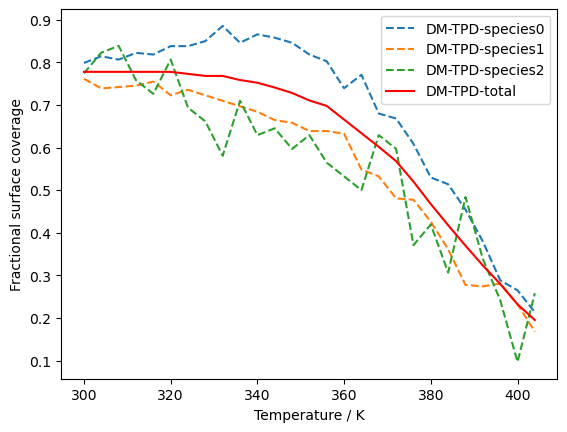

In [8]:
for i in range(3):
    plt.plot(DM_TPD['temp0'],DM_TPD['theta0'][i],label=f'DM-TPD-species{i}',linestyle='--')
plt.plot(DM_TPD['temp0'],np.sum(DM_TPD['pops0'],axis=0)/sim_TPD.n_sites,label='DM-TPD-total',c='r')
plt.ylabel('Fractional surface coverage')
plt.xlabel('Temperature / K')
plt.legend()
plt.show()
